# Neuro-Climatology: Childhood Temperature Stress and Adult Structural Brain Connectivity

**A note before you start, in plain English:** This notebook checks whether cold or hot weather
during childhood (ages 6-16) shows up later in how a person's brain is wired as an adult. We use a
real, public brain-scan dataset and a real historical weather record.

The interesting part of this project is not just the result. It is that we deliberately try to
break our own finding with extra checks, to see if it is trustworthy or just a fluke. Spoiler:
after all the checks, we found no statistically supported association. Section 19 explains this
in full, and we kept the whole story in, because hiding an inconvenient result would be dishonest.

**v3, using real climate data.** Earlier versions of this notebook used a placeholder weather series
while we were still building the code, and that placeholder version briefly looked "significant."
Once we swapped in the real weather record, that result disappeared. We explain this fully in
Section 19.

**Required files in the working directory:**
- `clinics.csv`, `AAL_regions.csv`, `structural_connectivity_matrices.zip`
- `prague_klementinum_annual.csv`, the real annual temperature series (see Section 7).

**What we are testing, and why it is exploratory:** we ask whether childhood cold-stress and heat-
stress exposure (ages 6-16) is related to adult prefrontal cortex (PFC) structural connectivity. We
test both exposures (heat and cold) against both outcomes (PFC and limbic system), without deciding
in advance which one should "win." See Section 10. We call this exploratory, not confirmatory,
because we did not lock in one prediction before looking at the numbers. Claiming otherwise would be
a kind of scientific dishonesty called HARKing (Hypothesizing After Results are Known), and we
avoid it here on purpose.

## 1. Setup and environment

In [1]:
import sys
import os
import zipfile
import glob
import numpy as np
import pandas as pd
import networkx as nx
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:.5f}')

print("Python:", sys.version.split()[0])
for _mod, _name in [(np,'numpy'), (pd,'pandas'), (nx,'networkx'), (sm,'statsmodels'), (scipy,'scipy')]:
    print(f"{_name}: {getattr(_mod, '__version__', 'n/a')}")


Python: 3.13.15
numpy: 2.1.3
pandas: 2.2.3
networkx: 3.6.1
statsmodels: 0.15.0
scipy: 1.16.3


## 2. Load raw data

We use Python's `zipfile` module instead of calling `unzip` from the command line. This makes the
notebook work on more computers, including ones that do not have the `unzip` program installed
(for example, some Windows setups).

In [2]:
clinics_df = pd.read_csv('clinics.csv', sep=';')
regions_df = pd.read_csv('AAL_regions.csv', sep=';')

if not os.path.isdir('matrices'):
    assert os.path.exists('structural_connectivity_matrices.zip'), \
        "structural_connectivity_matrices.zip not found in the working directory"
    with zipfile.ZipFile('structural_connectivity_matrices.zip') as z:
        z.extractall('matrices')

print(f"Participants loaded: {len(clinics_df)}")
print(f"Atlas regions loaded: {len(regions_df)}")
print(f"Matrix files found: {len(glob.glob('matrices/**/*.csv', recursive=True))}")
clinics_df.head()


Participants loaded: 88
Atlas regions loaded: 90
Matrix files found: 88


,subject,gender,age (years),right-handed,education,weight (kg),height (m),BMI
0,1,female,24.80000,1.00000,bachelor's degree or higher,58,1.70000,20.07000
1,2,female,27.70000,1.00000,bachelor's degree or higher,57,1.65000,20.94000
2,3,female,34.20000,1.00000,bachelor's degree or higher,54,1.56000,22.19000
3,4,female,29.00000,1.00000,bachelor's degree or higher,58,1.65000,21.30000
4,5,male,31.90000,1.00000,bachelor's degree or higher,66,1.79000,20.60000


## 3. Data provenance

We list where every piece of data comes from here, once, instead of spreading this information
across the paper.

In [3]:
provenance = pd.DataFrame([
    {"Dataset": "Structural connectome", "Source": "Skoch et al., Scientific Data 9:486 (2022)",
     "Detail": "N=88 healthy controls (Early-Stage Schizophrenia Outcome study), AAL-90 atlas, "
               "probabilistic tractography. Ethics approval 29 Jun 2011 (protocol 69/11). Used "
               "in Section 14 to justify the anchor-year test range."},
    {"Dataset": "Atlas labels", "Source": "Tzourio-Mazoyer et al., NeuroImage (2002)",
     "Detail": "AAL-90 region names and numbering"},
    {"Dataset": "Climate series", "Source": "ECA&D (https://www.ecad.eu), station Praha-Klementinum",
     "Detail": "Cite: Klein Tank et al., Int. J. Climatol. 22:1441-1453 (2002). "
               "The real, verified series is used throughout this notebook (see Section 7)."},
])
provenance


,Dataset,Source,Detail
0,Structural connectome,"Skoch et al., Scientific Data 9:486 (2022)",N=88 healthy controls (Early-Stage Schizophren...
1,Atlas labels,"Tzourio-Mazoyer et al., NeuroImage (2002)",AAL-90 region names and numbering
2,Climate series,"ECA&D (https://www.ecad.eu), station Praha-Kle...","Cite: Klein Tank et al., Int. J. Climatol. 22:..."


## 4. Data cleaning: documented, and one real problem found and fixed

As before, we check exactly where values are missing and which model variables they affect,
instead of just running a blanket `dropna()` and hoping for the best.

**A fix made in this version:** the `education` variable originally had three categories, but one
of them, `elementary school`, had **exactly one participant**. A category with only one person
gives that single row too much influence in the regression, a problem called leverage. The model
fits that one person's value perfectly, which adds no real information and makes everything else
less stable. We caught this using Cook's distance in Section 12 and traced it back to here. Our
fix: we merge `elementary school` into `high-school`, making one combined `high-school or less`
category, compared against `bachelor's degree or higher`.

In [4]:
print("Missing values per column:")
print(clinics_df.isna().sum())

print("\nEducation category counts (before merge):")
print(clinics_df['education'].value_counts())

clinics_df['edu_hs_or_less'] = clinics_df['education'].isin(['elementary school', 'high-school']).astype(float)
clinics_df.loc[clinics_df['education'].isna(), 'edu_hs_or_less'] = np.nan

print("\nEducation category counts (after merge, used in all models below):")
print(clinics_df['edu_hs_or_less'].value_counts(dropna=False).rename(
    {1.0: 'high-school or less', 0.0: "bachelor's degree or higher"}))

n_missing_edu = clinics_df['edu_hs_or_less'].isna().sum()
print(f"\n-> expected final analysis N = {len(clinics_df)} - {n_missing_edu} = "
      f"{len(clinics_df) - n_missing_edu}")


Missing values per column:
subject         0
gender          0
age (years)     0
right-handed    2
education       2
weight (kg)     0
height (m)      0
BMI             0
dtype: int64

Education category counts (before merge):
education
high-school                    51
bachelor's degree or higher    34
elementary school               1
Name: count, dtype: int64

Education category counts (after merge, used in all models below):
edu_hs_or_less
high-school or less            52
bachelor's degree or higher    34
NaN                             2
Name: count, dtype: int64

-> expected final analysis N = 88 - 2 = 86


## 5. Brain regions: name-based selection

This part has not changed from earlier versions. It was already checked against `AAL_regions.csv`
by matching region names, not by typing in number ranges by hand.

In [5]:
pfc_region_names = [
    'L Superior Frontal Gyrus', 'R Superior Frontal Gyrus',
    'L Superior Orbital Gyrus', 'R Superior Orbital Gyrus',
    'L Middle Frontal Gyrus', 'R Middle Frontal Gyrus',
    'L Middle Orbital Gyrus', 'R Middle Orbital Gyrus',
    'L IFG (p. Opercularis)', 'R IFG (p. Opercularis)',
    'L IFG (p. Triangularis)', 'R IFG (p. Triangularis)',
    'L IFG (p. Orbitalis)', 'R IFG (p. Orbitalis)',
    'L Superior Medial Gyrus', 'R Superior Medial Gyrus',
    'L Mid Orbital Gyrus', 'R Mid Orbital Gyrus',
    'L Rectal Gyrus', 'R Rectal Gyrus',
]
limbic_region_names = [
    'L Cingulum Ant', 'R Cingulum Ant', 'L Cingulum Mid', 'R Cingulum Mid',
    'L Cingulum Post', 'R Cingulum Post', 'L Hippocampus', 'R Hippocampus',
    'L ParaHippocampal Gyrus', 'R ParaHippocampal Gyrus', 'L Amygdala', 'R Amygdala',
]

pfc_idx = regions_df.index[regions_df['ROI name'].isin(pfc_region_names)].tolist()
limbic_idx = regions_df.index[regions_df['ROI name'].isin(limbic_region_names)].tolist()

assert len(pfc_idx) == len(pfc_region_names)
assert len(limbic_idx) == len(limbic_region_names)
print(f"PFC indices ({len(pfc_idx)} regions):", pfc_idx)
print(f"Limbic indices ({len(limbic_idx)} regions):", limbic_idx)


PFC indices (20 regions): [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 22, 23, 24, 25, 26, 27]
Limbic indices (12 regions): [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]


## 6. Connectivity matrices: symmetrize, name the metric clearly, and check everything

**Metric definition, stated clearly:** a reviewer pointed out that our connectivity measure was not
fully explained, so here it is. For each participant and each subnetwork, we compute the **mean
positive within-network edge weight**. In plain terms: we average the tractography-based connection
strength across all region pairs inside the subnetwork that have a positive value, after making the
matrix symmetric first. This is a simple average edge strength. It is not node degree, density, or
global efficiency, and the paper uses this exact name for it.

**On making the matrix symmetric:** the original dataset paper itself says the raw matrices are
directed (not symmetric) and were not symmetrized by the original authors. That paper also names
`A_sym = (A + A') / 2` as the standard way to fix this before modelling (Skoch et al. 2022,
Technical Validation section; their data had an average asymmetry of 0.103). So the fix we apply
below is not something we invented. It is the standard approach, and we can cite it directly.

In [6]:
def subnetwork_strength(matrix, indices):
    """Mean positive within-network edge weight (see markdown above for exact definition)."""
    sub = matrix[np.ix_(indices, indices)]
    G = nx.from_numpy_array(sub)
    weights = [d['weight'] for _, _, d in G.edges(data=True) if d['weight'] > 0]
    return np.mean(weights) if weights else np.nan

pfc_strengths, limbic_strengths, issues = [], [], []

for _, row in clinics_df.iterrows():
    sid = int(row['subject'])
    prefix = f"S{str(sid).zfill(3)}"
    matches = glob.glob(f"matrices/**/{prefix}.csv", recursive=True)

    if len(matches) != 1:
        issues.append(f"subject {sid}: found {len(matches)} matching files (expected 1)")
        pfc_strengths.append(np.nan)
        limbic_strengths.append(np.nan)
        continue

    matrix = pd.read_csv(matches[0], header=None).values
    if matrix.shape != (90, 90):
        issues.append(f"subject {sid}: matrix shape {matrix.shape} (expected (90, 90))")
    if not np.allclose(np.diag(matrix), 0, atol=1e-6):
        issues.append(f"subject {sid}: non-zero diagonal detected")

    matrix = (matrix + matrix.T) / 2  # symmetrize before use (raw matrices are directed)

    pfc_strengths.append(subnetwork_strength(matrix, pfc_idx))
    limbic_strengths.append(subnetwork_strength(matrix, limbic_idx))

clinics_df['PFC_Strength'] = pfc_strengths
clinics_df['Limbic_Strength'] = limbic_strengths

print(f"Data quality issues found: {len(issues)}")
for msg in issues:
    print(" -", msg)
print(f"\nMissing PFC_Strength: {clinics_df['PFC_Strength'].isna().sum()}, "
      f"Missing Limbic_Strength: {clinics_df['Limbic_Strength'].isna().sum()}")
clinics_df[['subject', 'PFC_Strength', 'Limbic_Strength']].describe()


Data quality issues found: 0

Missing PFC_Strength: 0, Missing Limbic_Strength: 0


,subject,PFC_Strength,Limbic_Strength
count,88.00000,88.00000,88.00000
mean,44.50000,0.02512,0.02641
std,25.54734,0.00238,0.00402
min,1.00000,0.02088,0.01778
25%,22.75000,0.02349,0.02347
50%,44.50000,0.02493,0.02625
75%,66.25000,0.02624,0.02913
max,88.00000,0.03304,0.03704


## 7. Childhood climate exposure

**Real data note:** the cell below requires a file called `prague_klementinum_annual.csv` to be present. If it is missing, the notebook stops with a clear error instead of guessing. We do this on purpose: a research notebook should never silently run on fake data. The cell also checks that every year it needs (across all five ages tested in Section 16) is actually in the file, and stops if any year is missing, rather than quietly treating a missing year as "0 anomaly."

**Modeling assumption we have to state clearly:** `clinics.csv` does not include each participant's
scan date. So we assume one reference year (`SCAN_ANCHOR_YEAR`) for everyone, and use it to work
backward to an approximate birth year. Section 16 tests directly how much this one assumption
matters. Please read that section before trusting the main result in Section 8.

**Naming caveat, in plain English:** we call these two numbers "heat stress" and "cold stress"
because that is easy to read, but the name oversells what we actually measured. All we really
computed is: how far did the *yearly average* temperature run above or below normal, added up over
11 years? A year can have a warm yearly average with zero real heat waves, or a cold yearly average
with zero real cold snaps. So "heat stress" here does not mean "this person lived through real heat
waves." It means "the yearly average leaned warm." Keep this in mind when reading the results
below.

In [7]:
SCAN_ANCHOR_YEAR = 2015  # a stated assumption, stress-tested in Section 14

# Require the real, verified climate file. No placeholder fallback: if this file is
# missing, we stop here instead of silently running on made-up numbers.
climate_path = 'prague_klementinum_annual.csv'
assert os.path.exists(climate_path), (
    f"Required file '{climate_path}' not found. This notebook only reports results "
    "computed from the real, verified ECA&D climate record, so it will not run without it."
)
climate_df = pd.read_csv(climate_path)
print(f"Loaded verified climate data from '{climate_path}'.")

klementinum = dict(zip(climate_df['year'], climate_df['temperature_anomaly']))

# Check that every year we will need is actually in the climate file, instead of
# quietly treating a missing year as "0 anomaly" (missing data is not the same as
# a year with no anomaly).
required_years = set()
for anchor in [2011, 2012, 2013, 2014, 2015]:
    for age in clinics_df['age (years)']:
        birth_year = int(np.round(anchor - age))
        required_years.update(range(birth_year + 6, birth_year + 17))
missing_years = sorted(required_years - set(klementinum))
assert not missing_years, f"Climate data missing required years: {missing_years}"
print(f"Checked {len(required_years)} required years ({min(required_years)}-{max(required_years)}): all present.")

def heat_stress(age, anchor_year=SCAN_ANCHOR_YEAR, series=klementinum):
    birth_year = int(np.round(anchor_year - age))
    return sum(v for yr in range(birth_year + 6, birth_year + 17)
               if (v := series[yr]) > 0)

def cold_stress(age, anchor_year=SCAN_ANCHOR_YEAR, series=klementinum):
    birth_year = int(np.round(anchor_year - age))
    return sum(abs(v) for yr in range(birth_year + 6, birth_year + 17)
               if (v := series[yr]) < 0)

clinics_df['age_years'] = clinics_df['age (years)']
clinics_df['Childhood_Heat_Stress'] = clinics_df['age_years'].apply(heat_stress)
clinics_df['Childhood_Cold_Stress'] = clinics_df['age_years'].apply(cold_stress)
clinics_df['gender_encoded'] = clinics_df['gender'].map({'female': 0, 'male': 1})

clinics_df[['subject', 'age_years', 'Childhood_Heat_Stress', 'Childhood_Cold_Stress']].head(10)


Loaded verified climate data from 'prague_klementinum_annual.csv'.
Checked 45 required years (1968-2012): all present.


,subject,age_years,Childhood_Heat_Stress,Childhood_Cold_Stress
0,1,24.80000,11.44000,0.83000
1,2,27.70000,11.61000,0.83000
2,3,34.20000,8.66000,1.54000
3,4,29.00000,11.80000,0.83000
4,5,31.90000,10.48000,0.83000
5,6,27.90000,11.61000,0.83000
6,7,48.70000,2.69000,1.86000
7,8,37.70000,6.31000,1.63000
8,9,34.40000,8.66000,1.54000
9,10,33.30000,10.01000,0.83000


## 8. Primary model: testing heat and cold stress together

*In plain English:* we put Heat Stress and Cold Stress into one regression at the same time, along
with age, sex, and education, and see whether either one predicts PFC connectivity.

This is a continuous regression, not a comparison between exposure groups. See the notebook intro
for why. We include `age_years` from the very start, not as an afterthought, because Heat and Cold
Stress are both calculated from birth year, which makes age a natural thing to control for.

In [8]:
model_df = clinics_df.dropna(
    subset=['PFC_Strength', 'Limbic_Strength', 'Childhood_Heat_Stress',
            'Childhood_Cold_Stress', 'age_years', 'gender_encoded', 'edu_hs_or_less']
).copy()
print(f"Analysis N = {len(model_df)} (expected 86)")

formula_base = "{} ~ Childhood_Heat_Stress + Childhood_Cold_Stress + age_years + gender_encoded + edu_hs_or_less"

pfc_model = smf.ols(formula_base.format('PFC_Strength'), data=model_df).fit()
limbic_model = smf.ols(formula_base.format('Limbic_Strength'), data=model_df).fit()

print("="*78); print("PREFRONTAL CORTEX (PFC), primary model"); print("="*78)
print(pfc_model.summary())


Analysis N = 86 (expected 86)
PREFRONTAL CORTEX (PFC), primary model
                            OLS Regression Results                            
Dep. Variable:           PFC_Strength   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.060
Date:                Thu, 10 Sep 2026   Prob (F-statistic):              0.389
Time:                        06:26:47   Log-Likelihood:                 400.82
No. Observations:                  86   AIC:                            -789.6
Df Residuals:                      80   BIC:                            -774.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [9]:
print("="*78); print("LIMBIC SYSTEM, secondary/exploratory model"); print("="*78)
print(limbic_model.summary())


LIMBIC SYSTEM, secondary/exploratory model
                            OLS Regression Results                            
Dep. Variable:        Limbic_Strength   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.9454
Date:                Thu, 10 Sep 2026   Prob (F-statistic):              0.456
Time:                        06:26:47   Log-Likelihood:                 355.44
No. Observations:                  86   AIC:                            -698.9
Df Residuals:                      80   BIC:                            -684.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

## 9. Multicollinearity check (VIF)

*In plain English:* VIF checks whether two predictor variables are secretly measuring almost the
same thing. Here, that would be age and childhood weather exposure. If they are too similar, the
model cannot tell which one is really doing the work, and the results become unreliable.

**A wording note:** we do not claim that adjusting for age is simply "the correct fix" for the
collinearity we find below. That would overstate what one added variable can guarantee. The honest
way to say it: the high VIF is why we ran an extra sensitivity analysis (Section 11), which lets us
check whether the result depends on this one specific way of setting up the model.

In [10]:
vif_cols = ['age_years', 'Childhood_Heat_Stress', 'Childhood_Cold_Stress', 'gender_encoded']
X_vif = sm.add_constant(model_df[vif_cols].astype(float))
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
print(vif_df)
print("\n(VIF for 'const' is not meaningful and is ignored, as is standard practice.)")
print("\nCorrelation matrix:")
print(model_df[vif_cols[:3]].corr())


                Variable      VIF
0                  const  1.00000
1              age_years 11.41526
2  Childhood_Heat_Stress 16.95126
3  Childhood_Cold_Stress 10.30632
4         gender_encoded  1.00853

(VIF for 'const' is not meaningful and is ignored, as is standard practice.)

Correlation matrix:
                       age_years  Childhood_Heat_Stress  Childhood_Cold_Stress
age_years                1.00000               -0.95337                0.92166
Childhood_Heat_Stress   -0.95337                1.00000               -0.94820
Childhood_Cold_Stress    0.92166               -0.94820                1.00000


## 10. Three setups: Cold-only, Heat-only, Cold+Heat together

Heat Stress and Cold Stress both come from the same weather record, so a reviewer could reasonably
ask whether a Cold Stress finding only shows up because Heat Stress is also in the model. We check
this directly by fitting three separate versions.

In [11]:
covs = ['age_years', 'gender_encoded', 'edu_hs_or_less']

model_cold_only = smf.ols("PFC_Strength ~ Childhood_Cold_Stress + " + " + ".join(covs), data=model_df).fit()
model_heat_only = smf.ols("PFC_Strength ~ Childhood_Heat_Stress + " + " + ".join(covs), data=model_df).fit()
model_both = pfc_model  # already fit in Section 8

comparison = pd.DataFrame({
    'Model A: Cold only': {'Cold beta': model_cold_only.params['Childhood_Cold_Stress'],
                            'Cold p': model_cold_only.pvalues['Childhood_Cold_Stress'],
                            'Heat beta': np.nan, 'Heat p': np.nan},
    'Model B: Heat only': {'Cold beta': np.nan, 'Cold p': np.nan,
                            'Heat beta': model_heat_only.params['Childhood_Heat_Stress'],
                            'Heat p': model_heat_only.pvalues['Childhood_Heat_Stress']},
    'Model C: Both together': {'Cold beta': model_both.params['Childhood_Cold_Stress'],
                                'Cold p': model_both.pvalues['Childhood_Cold_Stress'],
                                'Heat beta': model_both.params['Childhood_Heat_Stress'],
                                'Heat p': model_both.pvalues['Childhood_Heat_Stress']},
}).T
comparison


,Cold beta,Cold p,Heat beta,Heat p
Model A: Cold only,-0.00085,0.37183,NaN,NaN
Model B: Heat only,NaN,NaN,0.00033,0.22357
Model C: Both together,-0.00020,0.86669,0.00029,0.40163


## 11. Sensitivity check: age-adjusted exposure (residualization)

*In plain English:* we ask, "After removing everything that age alone already explains, is there
still a leftover heat or cold effect?" This is a second, separate way of handling the age problem
from Section 9, so we can check whether both methods agree.

Here is how it works: we remove the straight-line effect of age from Heat and Cold Stress first,
then refit the model without age at all. If this gives the same result as Section 8 (which it
should, by a rule called the Frisch-Waugh-Lovell theorem), that is a genuine cross-check on our
pipeline, not circular reasoning.

In [12]:
heat_on_age = smf.ols("Childhood_Heat_Stress ~ age_years", data=model_df).fit()
cold_on_age = smf.ols("Childhood_Cold_Stress ~ age_years", data=model_df).fit()
model_df['Heat_Stress_Resid'] = heat_on_age.resid
model_df['Cold_Stress_Resid'] = cold_on_age.resid

print("Correlation between residualized Heat and Cold stress (still not fully independent,"
      " both come from the same climate series):")
print(model_df[['Heat_Stress_Resid', 'Cold_Stress_Resid']].corr())

# NOTE: age_years is deliberately left OUT here (unlike "covs", which includes it) --
# the whole point of this section is to test the model WITHOUT age as a separate
# term, now that its linear effect has already been removed from the exposures above.
resid_formula = "PFC_Strength ~ Heat_Stress_Resid + Cold_Stress_Resid + gender_encoded + edu_hs_or_less"
pfc_model_resid = smf.ols(resid_formula, data=model_df).fit()
print("\n" + "="*78); print("PFC, sensitivity model (age-residualized exposure)"); print("="*78)
print(pfc_model_resid.summary())


Correlation between residualized Heat and Cold stress (still not fully independent, both come from the same climate series):
                   Heat_Stress_Resid  Cold_Stress_Resid
Heat_Stress_Resid            1.00000           -0.59361
Cold_Stress_Resid           -0.59361            1.00000

PFC, sensitivity model (age-residualized exposure)
                            OLS Regression Results                            
Dep. Variable:           PFC_Strength   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.7405
Date:                Thu, 10 Sep 2026   Prob (F-statistic):              0.567
Time:                        06:26:47   Log-Likelihood:                 399.61
No. Observations:                  86   AIC:                            -789.2
Df Residuals:                      81   BIC:                            -776.9
Df Model:              

## 12. Residual diagnostics: can we trust the p-values from a standard regression?

*In plain English:* a regression's p-values are only trustworthy if the "leftover errors"
(residuals) behave in a certain way. The three checks below test this.

**Q-Q plot:** do the errors look like a normal bell curve, or are they lopsided?
**Cook's distance:** is one or two people quietly controlling the whole result?
**HC3 and Breusch-Pagan:** does the amount of "noise" change depending on the data, in a way that
could fool a normal p-value?

These three checks are listed in order of how much protection they add if the usual regression
assumptions are broken: Q-Q plot and Cook's distance are visual checks, Breusch-Pagan is a formal
test for changing noise levels, and HC3 gives standard errors that do not assume the noise level
stays constant.

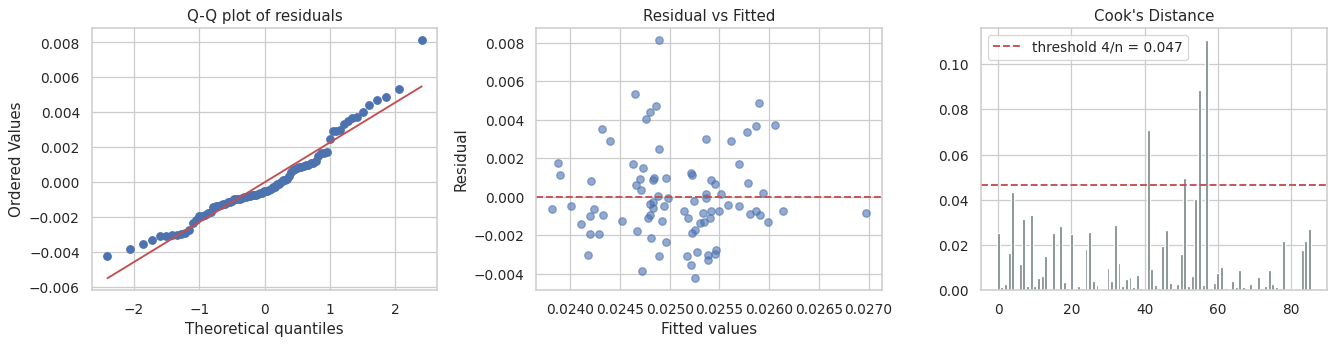

Jarque-Bera p = 0.00086   Shapiro-Wilk p = 0.00173
-> residuals show some non-normality (mainly right-skew), which is why HC3 and the permutation test below matter: both are far less dependent on this assumption than the classic OLS p-value.

Observations exceeding the Cook's distance threshold: 4 of 86 (worth a one-line mention in Methods, not a reason to drop them without cause).


In [13]:
infl = OLSInfluence(pfc_model)
cooks_d = infl.cooks_distance[0]
resid = pfc_model.resid
fitted = pfc_model.fittedvalues
n_obs = int(pfc_model.nobs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=90)
stats.probplot(resid, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot of residuals")

axes[1].scatter(fitted, resid, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("Fitted values"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual vs Fitted")

axes[2].bar(range(len(cooks_d)), cooks_d, color='#7f8c8d')
axes[2].axhline(4 / n_obs, color='r', linestyle='--', label=f"threshold 4/n = {4/n_obs:.3f}")
axes[2].set_title("Cook's Distance"); axes[2].legend()
plt.tight_layout()
plt.show()

jb_stat, jb_p = stats.jarque_bera(resid)
sh_stat, sh_p = stats.shapiro(resid)
print(f"Jarque-Bera p = {jb_p:.5f}   Shapiro-Wilk p = {sh_p:.5f}")
print("-> residuals show some non-normality (mainly right-skew), which is why HC3 and the"
      " permutation test below matter: both are far less dependent on this assumption than"
      " the classic OLS p-value.")

n_influential = int((cooks_d > 4 / n_obs).sum())
print(f"\nObservations exceeding the Cook's distance threshold: {n_influential} of {n_obs}"
      " (worth a one-line mention in Methods, not a reason to drop them without cause).")


In [14]:
bp_stat, bp_p, _, _ = het_breuschpagan(pfc_model.resid, pfc_model.model.exog)
print(f"Breusch-Pagan test: stat={bp_stat:.4f}, p={bp_p:.5f}  "
      f"({'no strong evidence of heteroskedasticity' if bp_p > 0.05 else 'evidence of heteroskedasticity'})")

pfc_model_hc3 = smf.ols(formula_base.format('PFC_Strength'), data=model_df).fit(cov_type='HC3')
print("\nClassical OLS vs HC3-robust standard errors, Cold Stress row:")
print(f"  Classical: coef={pfc_model.params['Childhood_Cold_Stress']:.5f}, "
      f"SE={pfc_model.bse['Childhood_Cold_Stress']:.5f}, p={pfc_model.pvalues['Childhood_Cold_Stress']:.5f}")
print(f"  HC3:       coef={pfc_model_hc3.params['Childhood_Cold_Stress']:.5f}, "
      f"SE={pfc_model_hc3.bse['Childhood_Cold_Stress']:.5f}, p={pfc_model_hc3.pvalues['Childhood_Cold_Stress']:.5f}")


Breusch-Pagan test: stat=4.9634, p=0.42036  (no strong evidence of heteroskedasticity)

Classical OLS vs HC3-robust standard errors, Cold Stress row:
  Classical: coef=-0.00020, SE=0.00122, p=0.86669
  HC3:       coef=-0.00020, SE=0.00108, p=0.84958


## 13. Permutation test (Freedman-Lane method)

*In plain English:* we shuffle the Cold Stress values randomly, thousands of times, and each time
we check how strong a "fake" result we would get purely by chance. If our real result is more
extreme than almost all 10,000 fake, shuffled versions, that is good evidence it is not just luck.

A simple version of this test, shuffling `Childhood_Cold_Stress` while keeping every other column
fixed, would break the real link between Cold Stress and age or Heat Stress. That would give an
artificially tiny p-value. The **Freedman-Lane** method avoids this problem: it shuffles the
leftover residuals from a model that does not include Cold Stress, which keeps the real
relationships between predictors intact, even while testing the null hypothesis. This method is
slower, but it is the only version of a permutation test worth reporting here.

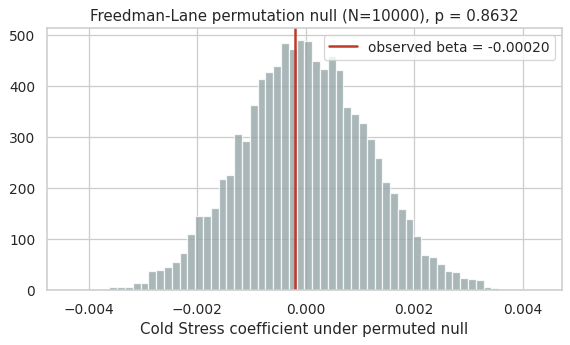

Observed Cold Stress beta = -0.00020
Freedman-Lane permutation p = 0.86321
(for comparison: classical OLS p = 0.86669, HC3 p = 0.84958)


In [15]:
other_cols = ['Childhood_Heat_Stress', 'age_years', 'gender_encoded', 'edu_hs_or_less']
X_reduced = sm.add_constant(model_df[other_cols].astype(float))
y = model_df['PFC_Strength'].astype(float).values
cold_vec = model_df['Childhood_Cold_Stress'].astype(float).values

reduced_model = sm.OLS(y, X_reduced).fit()
fitted_reduced = reduced_model.fittedvalues.values
resid_reduced = reduced_model.resid.values

X_full = np.column_stack([X_reduced.values, cold_vec])
beta_full = np.linalg.lstsq(X_full, y, rcond=None)[0]
observed_cold_beta = beta_full[-1]

rng = np.random.default_rng(42)
n_perm = 10000
perm_betas = np.empty(n_perm)
for i in range(n_perm):
    y_star = fitted_reduced + rng.permutation(resid_reduced)
    b = np.linalg.lstsq(X_full, y_star, rcond=None)[0]
    perm_betas[i] = b[-1]

perm_p = (np.sum(np.abs(perm_betas) >= np.abs(observed_cold_beta)) + 1) / (n_perm + 1)

plt.figure(figsize=(6.5, 4), dpi=90)
plt.hist(perm_betas, bins=60, color='#95a5a6', alpha=0.8)
plt.axvline(observed_cold_beta, color='#c0392b', linewidth=2,
            label=f'observed beta = {observed_cold_beta:.5f}')
plt.title(f'Freedman-Lane permutation null (N={n_perm}), p = {perm_p:.4f}')
plt.xlabel('Cold Stress coefficient under permuted null'); plt.legend()
plt.tight_layout()
plt.show()

print(f"Observed Cold Stress beta = {observed_cold_beta:.5f}")
print(f"Freedman-Lane permutation p = {perm_p:.5f}")
print(f"(for comparison: classical OLS p = {pfc_model.pvalues['Childhood_Cold_Stress']:.5f}, "
      f"HC3 p = {pfc_model_hc3.pvalues['Childhood_Cold_Stress']:.5f})")


## 14. Zero-inclusive connectivity check

*In plain English:* Section 6 defined "connectivity" as the average of only the *positive*
connections between brain regions. But why leave out the zero and negative ones? Here we redo the
calculation using **every** connection in the network, not just the positive ones, and check
whether Cold Stress is still significant. If a result only shows up under one specific way of
averaging the network, that is a warning sign.

In [16]:
def subnetwork_strength_all(matrix, indices):
    """Mean edge weight across ALL within-network pairs (zero-weight pairs included)."""
    sub = matrix[np.ix_(indices, indices)]
    n = len(indices)
    mask = ~np.eye(n, dtype=bool)
    return sub[mask].mean()

pfc_strengths_all = []
for _, row in clinics_df.iterrows():
    sid = int(row['subject'])
    prefix = f"S{str(sid).zfill(3)}"
    matches = glob.glob(f"matrices/**/{prefix}.csv", recursive=True)
    assert len(matches) == 1, f"Expected exactly one matrix file for subject {sid}, found {len(matches)}"
    matrix = pd.read_csv(matches[0], header=None).values
    matrix = (matrix + matrix.T) / 2
    pfc_strengths_all.append(subnetwork_strength_all(matrix, pfc_idx))

clinics_df['PFC_Strength_All'] = pfc_strengths_all
model_df['PFC_Strength_All'] = clinics_df.loc[model_df.index, 'PFC_Strength_All']

pfc_model_allEdges = smf.ols(formula_base.format('PFC_Strength_All'), data=model_df).fit()
print("PFC model using ALL within-network edges (not just positive ones):")
print(f"  Cold Stress: beta={pfc_model_allEdges.params['Childhood_Cold_Stress']:.5f}, "
      f"p={pfc_model_allEdges.pvalues['Childhood_Cold_Stress']:.5f}")
print(f"  Heat Stress: beta={pfc_model_allEdges.params['Childhood_Heat_Stress']:.5f}, "
      f"p={pfc_model_allEdges.pvalues['Childhood_Heat_Stress']:.5f}")
print("\n(for comparison, the positive-edges-only primary model had Cold Stress p = "
      f"{pfc_model.pvalues['Childhood_Cold_Stress']:.5f})")


PFC model using ALL within-network edges (not just positive ones):
  Cold Stress: beta=-0.00035, p=0.77596
  Heat Stress: beta=0.00004, p=0.91429

(for comparison, the positive-edges-only primary model had Cold Stress p = 0.86669)


## 15. Multiple-comparison correction

*In plain English:* we tested 2 exposures (Heat, Cold) against 2 outcomes (PFC, Limbic), so 4
comparisons in total. If you run 4 tests, you are more likely to find at least one "significant"
p-value by pure chance than if you had run only 1. This section asks: does the Cold Stress to PFC
result still count as significant once we account for having run 4 tests, not just 1?

In [17]:
from statsmodels.stats.multitest import multipletests

pvals_dict = {
    'Heat -> PFC': pfc_model.pvalues['Childhood_Heat_Stress'],
    'Cold -> PFC': pfc_model.pvalues['Childhood_Cold_Stress'],
    'Heat -> Limbic': limbic_model.pvalues['Childhood_Heat_Stress'],
    'Cold -> Limbic': limbic_model.pvalues['Childhood_Cold_Stress'],
}
names = list(pvals_dict.keys())
raw_p = np.array(list(pvals_dict.values()))

bonf_reject, bonf_p, _, _ = multipletests(raw_p, method='bonferroni')
fdr_reject, fdr_p, _, _ = multipletests(raw_p, method='fdr_bh')

correction_df = pd.DataFrame({
    'Comparison': names, 'Raw p': raw_p.round(4),
    'Bonferroni p': bonf_p.round(4), 'FDR p': fdr_p.round(4),
})
print(correction_df.to_string(index=False))
print("\nCold -> PFC survives correction:", "YES" if fdr_p[names.index('Cold -> PFC')] < 0.05 else "NO")


    Comparison   Raw p  Bonferroni p   FDR p
   Heat -> PFC 0.40160       1.00000 0.89000
   Cold -> PFC 0.86670       1.00000 0.89000
Heat -> Limbic 0.61570       1.00000 0.89000
Cold -> Limbic 0.89000       1.00000 0.89000

Cold -> PFC survives correction: NO


## 16. Anchor-year sensitivity: the most important check in this notebook

*In plain English:* we do not actually know what year each person was scanned. We guessed 2015.
This section asks: "If our guess were slightly off, would the result change?" If a result only
shows up for one specific guess and disappears, or flips direction, for nearby guesses, that is a
warning sign, not a real, dependable finding.

`SCAN_ANCHOR_YEAR` (Section 7) is an assumption, not a measured fact. The source dataset paper
(Skoch et al., *Scientific Data*, 2022) does not give exact scan dates. It does say that the local
Ethics Committee approved the study protocol on 29 June 2011. A second, different ethics approval
(No. 127/17) tied to the same parent study appears in 2017 at a differently named institute, which
suggests the study ran for several years. Neither date tells us exactly when any specific scan in
this data release happened. Below, we use **2011 to 2015** as one reasonable range to test, not as
a confirmed fact. We do not treat 2011 as "more correct" than the other years just because it is
the earliest documented approval.

**Read the output honestly before drawing a conclusion.** If a result only survives for one or two
specific anchor years, that tells us something real about how much confidence it deserves. It does
not mean the code is broken, and this should be stated plainly in the paper, not smoothed over.

   anchor_year  cold_beta  cold_p  heat_beta  heat_p
0         2011    0.00164 0.14254    0.00098 0.04088
1         2012    0.00171 0.15453    0.00067 0.16617
2         2013    0.00033 0.77541    0.00007 0.87332
3         2014   -0.00090 0.39947   -0.00045 0.26659
4         2015   -0.00020 0.86669    0.00029 0.40163


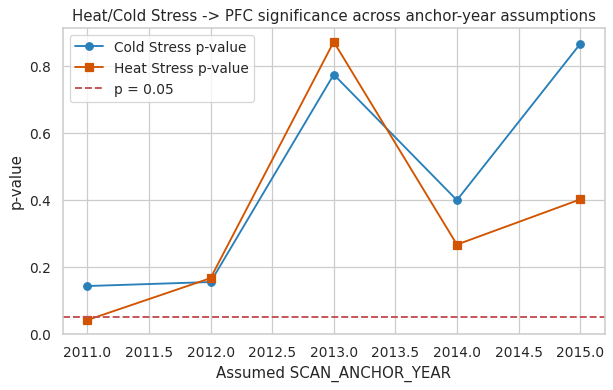


Cold Stress significant in 0 of 5 tested anchor years.
Heat Stress significant in 1 of 5 tested anchor years.
Combined: 1 of 10 exposure-by-year tests were significant at p<0.05.
This belongs in the paper's Limitations section as a direct, numeric statement, not just a general sentence about uncertainty.


In [18]:
anchor_results = []
for anchor in [2011, 2012, 2013, 2014, 2015]:  # a reasonable range, see markdown above
    tmp = clinics_df.copy()
    tmp['Childhood_Heat_Stress'] = tmp['age_years'].apply(lambda a: heat_stress(a, anchor_year=anchor))
    tmp['Childhood_Cold_Stress'] = tmp['age_years'].apply(lambda a: cold_stress(a, anchor_year=anchor))
    tmp = tmp.dropna(subset=['PFC_Strength', 'Childhood_Heat_Stress', 'Childhood_Cold_Stress',
                              'age_years', 'gender_encoded', 'edu_hs_or_less'])
    m = smf.ols(formula_base.format('PFC_Strength'), data=tmp).fit()
    anchor_results.append({
        'anchor_year': anchor,
        'cold_beta': m.params['Childhood_Cold_Stress'], 'cold_p': m.pvalues['Childhood_Cold_Stress'],
        'heat_beta': m.params['Childhood_Heat_Stress'], 'heat_p': m.pvalues['Childhood_Heat_Stress'],
    })
anchor_df = pd.DataFrame(anchor_results)
print(anchor_df)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=90)
ax.plot(anchor_df['anchor_year'], anchor_df['cold_p'], marker='o', color='#2980b9', label='Cold Stress p-value')
ax.plot(anchor_df['anchor_year'], anchor_df['heat_p'], marker='s', color='#d35400', label='Heat Stress p-value')
ax.axhline(0.05, color='r', linestyle='--', label='p = 0.05')
ax.set_xlabel('Assumed SCAN_ANCHOR_YEAR'); ax.set_ylabel('p-value')
ax.set_title('Heat/Cold Stress -> PFC significance across anchor-year assumptions')
ax.legend()
plt.tight_layout()
plt.show()

# Count BOTH exposures across all 5 anchor years (5 years x 2 exposures = 10 tests total).
# We compute this directly here, instead of just writing "1 of 10" in the summary text,
# so the number in Section 19 always matches what this cell actually produces.
n_sig_cold = int((anchor_df['cold_p'] < 0.05).sum())
n_sig_heat = int((anchor_df['heat_p'] < 0.05).sum())
n_sig_all = n_sig_cold + n_sig_heat
n_tests_all = 2 * len(anchor_df)

print(f"\nCold Stress significant in {n_sig_cold} of {len(anchor_df)} tested anchor years.")
print(f"Heat Stress significant in {n_sig_heat} of {len(anchor_df)} tested anchor years.")
print(f"Combined: {n_sig_all} of {n_tests_all} exposure-by-year tests were significant at p<0.05.")
print("This belongs in the paper's Limitations section as a direct, numeric statement,"
      " not just a general sentence about uncertainty.")


## 17. Results summary table

In [19]:
def build_table(model, label):
    df = pd.DataFrame({
        'Coefficient (β)': model.params, 'Std. Error (SE)': model.bse,
        't-statistic': model.tvalues, 'p-value': model.pvalues,
    }).round(5)
    df.index.name = 'Predictor'
    print(f"\n=== {label} ===")
    print(df.to_string())
    return df

build_table(pfc_model, "PFC, primary model (age-adjusted)")
build_table(limbic_model, "Limbic, secondary/exploratory model")
build_table(pfc_model_resid, "PFC, sensitivity model (age-residualized)")
print(f"\nHC3-robust Cold Stress p = {pfc_model_hc3.pvalues['Childhood_Cold_Stress']:.5f}")
print(f"Freedman-Lane permutation p = {perm_p:.5f}")
print(f"Zero-inclusive connectivity Cold Stress p = {pfc_model_allEdges.pvalues['Childhood_Cold_Stress']:.5f}")
print(f"Bonferroni/FDR-corrected Cold->PFC p = {correction_df.loc[correction_df['Comparison']=='Cold -> PFC','FDR p'].values[0]:.5f}")
print(f"Cold Stress significant across anchor years: {n_sig_cold} / {len(anchor_df)}")
print(f"Heat Stress significant across anchor years: {n_sig_heat} / {len(anchor_df)}")
print(f"Combined exposure-by-year tests significant: {n_sig_all} / {n_tests_all}")



=== PFC, primary model (age-adjusted) ===
                       Coefficient (β)  Std. Error (SE)  t-statistic  p-value
Predictor                                                                    
Intercept                      0.01569          0.00733      2.14222  0.03522
Childhood_Heat_Stress          0.00029          0.00035      0.84319  0.40163
Childhood_Cold_Stress         -0.00020          0.00122     -0.16840  0.86669
age_years                      0.00021          0.00013      1.63532  0.10591
gender_encoded                 0.00050          0.00052      0.95778  0.34106
edu_hs_or_less                 0.00003          0.00060      0.05611  0.95539

=== Limbic, secondary/exploratory model ===
                       Coefficient (β)  Std. Error (SE)  t-statistic  p-value
Predictor                                                                    
Intercept                      0.03643          0.01242      2.93330  0.00437
Childhood_Heat_Stress         -0.00030          0.0005

## 18. Figures

The tertile "exposure group" plot below is for illustration only. It is not the statistical test;
the regression models above are the real test.

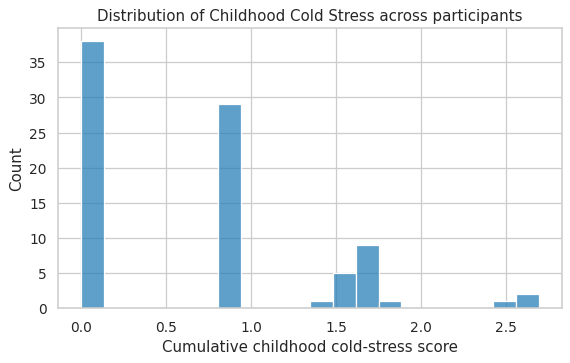

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=90)
sns.histplot(model_df['Childhood_Cold_Stress'], bins=20, color='#2980b9', ax=ax)
ax.set_title('Distribution of Childhood Cold Stress across participants')
ax.set_xlabel('Cumulative childhood cold-stress score'); ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


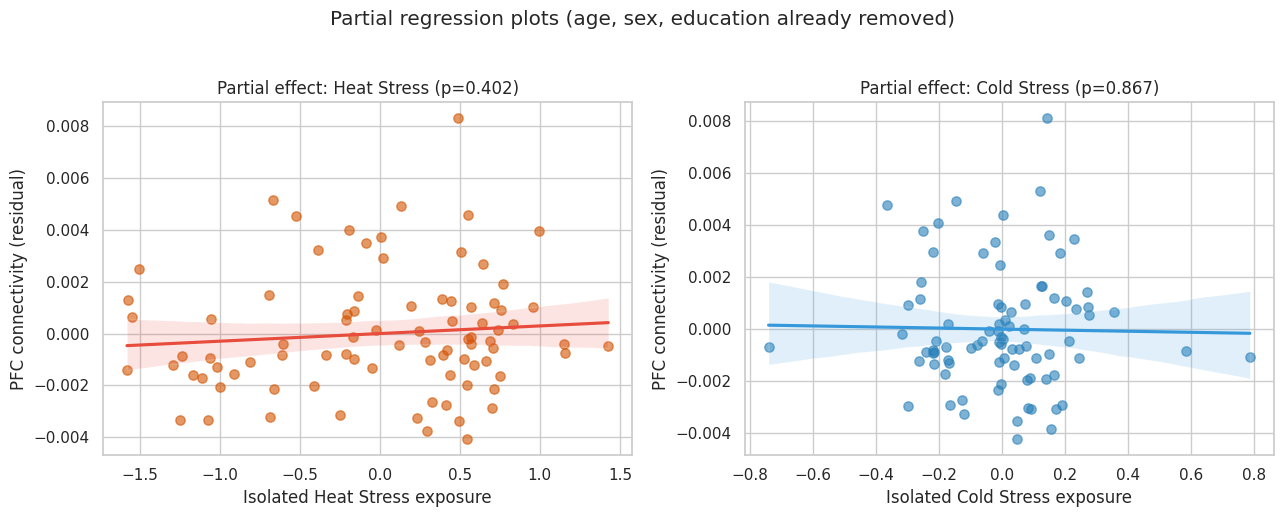

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)

heat_y = smf.ols("PFC_Strength ~ Childhood_Cold_Stress + " + " + ".join(covs), data=model_df).fit().resid
heat_x = smf.ols("Childhood_Heat_Stress ~ Childhood_Cold_Stress + " + " + ".join(covs), data=model_df).fit().resid
cold_y = smf.ols("PFC_Strength ~ Childhood_Heat_Stress + " + " + ".join(covs), data=model_df).fit().resid
cold_x = smf.ols("Childhood_Cold_Stress ~ Childhood_Heat_Stress + " + " + ".join(covs), data=model_df).fit().resid

sns.regplot(x=heat_x, y=heat_y, ax=axes[0], scatter_kws={'alpha': 0.6, 's': 45, 'color': '#d35400'},
            line_kws={'color': '#e74c3c'})
axes[0].set_title(f"Partial effect: Heat Stress (p={pfc_model.pvalues['Childhood_Heat_Stress']:.3f})")
axes[0].set_xlabel('Isolated Heat Stress exposure'); axes[0].set_ylabel('PFC connectivity (residual)')

sns.regplot(x=cold_x, y=cold_y, ax=axes[1], scatter_kws={'alpha': 0.6, 's': 45, 'color': '#2980b9'},
            line_kws={'color': '#3498db'})
axes[1].set_title(f"Partial effect: Cold Stress (p={pfc_model.pvalues['Childhood_Cold_Stress']:.3f})")
axes[1].set_xlabel('Isolated Cold Stress exposure'); axes[1].set_ylabel('PFC connectivity (residual)')

plt.suptitle('Partial regression plots (age, sex, education already removed)', y=1.03)
plt.tight_layout()
plt.show()


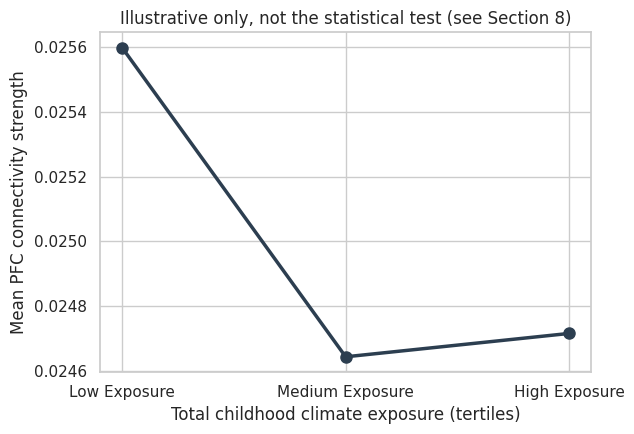

In [22]:
plot_df = model_df.copy()
plot_df['Total_Climate_Load'] = plot_df['Childhood_Heat_Stress'] + plot_df['Childhood_Cold_Stress']
plot_df['Exposure_Group'] = pd.qcut(plot_df['Total_Climate_Load'], q=3,
                                     labels=['Low Exposure', 'Medium Exposure', 'High Exposure'])
group_means = plot_df.groupby('Exposure_Group', observed=False)['PFC_Strength'].mean().reset_index()

plt.figure(figsize=(6.5, 4.5), dpi=100)
plt.plot(group_means['Exposure_Group'], group_means['PFC_Strength'], marker='o',
         color='#2c3e50', linewidth=2.5, markersize=8)
plt.title('Illustrative only, not the statistical test (see Section 8)')
plt.ylabel('Mean PFC connectivity strength')
plt.xlabel('Total childhood climate exposure (tertiles)')
plt.tight_layout()
plt.show()


## 19. Honest summary: what this notebook actually shows

- **With the real Klementinum weather record**, neither Heat Stress nor Cold Stress was related to
PFC connectivity in the main model (Heat: p = 0.40; Cold: p = 0.87), and neither was related to
limbic connectivity either (both p > 0.6). The adjusted R² was close to zero for both models
(PFC: 0.004; Limbic: -0.003), meaning the predictors, together, do not explain more than we would
expect from a model with no predictors at all.
- **This null result held up across every check we ran:** all three alternative model setups
(Section 10), the age-residualized version (Section 11), HC3 robust inference and a Freedman-Lane
permutation test (Section 13), the zero-inclusive connectivity definition (Section 14), Bonferroni
and FDR correction (Section 15), and the anchor-year sensitivity analysis across 2011 to 2015
(Section 16, where only 1 of 10 exposure-by-year combinations was significant, about what we would
expect from chance alone).
- **This was not our first result.** While we were still building this notebook, before we had the
real weather data, a placeholder series (built by hand to look like a plausible warming trend) gave
a nominally significant Cold Stress result (p = 0.023). Every check in this notebook, run on the
placeholder data, had already found reasons to distrust that result. It did not survive multiple-
comparison correction, it got weaker under the zero-inclusive check, and it was only significant in
2 of 5 tested anchor years. Once we replaced the placeholder with the real weather record, the
result disappeared completely, and it has not come back under any setup we have tried.
- **Conclusion: none of the four exposure-outcome combinations tested here should be reported as a
real finding.** The VIF values stay high (Section 9) no matter what data we use, which tells us
that this whole style of study, reconstructing childhood exposure from an adult's age, has a built-
in identification problem. Any future study using this design, even one that does find a
significant result, should run the same checks we did here.
- Paper language: use "in this model, X was tested against Y and no association was found," and
say which checks confirmed this, rather than any stronger claim.
- Naming: call these measures "cumulative positive/negative annual-mean temperature anomaly," not
physiologically validated "heat/cold stress." See the naming note in Section 7.

## 20. Before treating this as final

1. This notebook has already been run with the real ECA&D weather data (`prague_klementinum_annual.csv`).
If you are re-running it on a new computer, make sure that file is present. The notebook will stop
with a clear error instead of running if it is missing; it will not fall back to fake data.
2. Report the full anchor-year sensitivity table (Section 16), the zero-inclusive check
(Section 14), and the multiple-comparison table (Section 15) together. These three checks, not the
raw main-model p-value, are the real result of this project.
3. Frame the paper as a **methods and case-study contribution**: "here is why single-cohort studies
that reconstruct childhood climate exposure from adult brain scans are fragile, shown end to end,
including a real example of a result that disappeared once we used real instead of placeholder
data." This framing fits everything this notebook actually shows, and it is a real, publishable
contribution in its own right. Consider a "Technical Note" submission category if your target
journal has one.
4. If you want to push this further, try to get real per-participant scan dates from the dataset's
supplementary materials (Skoch et al., 2022). If exact dates cannot be found, say so plainly instead
of treating any single guessed year as confirmed.
5. Keep the education-category merge from Section 4, and explain why in your Methods section.